# Data Exploration: Distributions and Skew

This notebook summarizes variable distributions across renal/MMA/Pa renal datasets.

**Why this matters:** Many biomarkers are right-skewed. The analysis files often use natural-log transforms (`LN_*` columns). Skew-aware methods (non-parametric tests, effect sizes, random forests on transformed features) are appropriate when normality is not met.

In [1]:
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import seaborn as sns
except ModuleNotFoundError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])
    import seaborn as sns

from scipy.stats import skew, kurtosis

sns.set_theme(style="whitegrid")
pd.set_option('display.max_rows', 200)

In [2]:
DATASETS = {
    'renal_all': 'renal_all.csv',
    'renal_notransplant': 'renal_notransplant.csv',
    'renal_transplant': 'renal_transplant.csv',
    'mma_non-transplanted': 'mma_non-transplanted.csv',
    'mma_post-transplant': 'mma_post-transplant.csv',
    'Pa_renal_nontransplanted': 'Pa_renal_nontransplanted.csv',
    'pa_renal_post-transplanted': 'pa_renal_post-transplanted.csv',
}

RAW_BIOMARKERS = ['TNFR1', 'TNFR2', 'KIM1', 'FGF21', 'GDF15', 'NGAL', 'RBP4', 'TGFb1', 'sMMA']
LN_BIOMARKERS = ['LN_TNFR1', 'LN_TNFR2', 'LN_KIM1', 'LN_FGF21', 'LN_GDF15', 'LN_NGAL', 'LN_RBP4', 'LN_TGFb1', 'LN_sMMA', 'LN_SerumMMA']

CLINICAL_NUMERIC = [
    'Protein_Creatinine_Ratio', 'Albumin_excretion_24h', 'Protein_excretion_24h',
    'Arginine_Citrulline_ratio', 'Arg_Citrulline_Ratio',
    'Uric_Acid', 'FEUA', 'PropOx_60', 'PropOx_120',
    'Creatinine', 'Screatinine_mg_dL', 'Cystatin_C', 'Cystatin_mg_L',
    'eGFR_SCr', 'eGFR_CystatinC', 'eGFR_CyC',
]

loaded = {name: pd.read_csv(path) for name, path in DATASETS.items()}
for name, df in loaded.items():
    print(f'{name}: {df.shape[0]} rows, {df.shape[1]} columns')

renal_all: 96 rows, 37 columns
renal_notransplant: 111 rows, 37 columns
renal_transplant: 15 rows, 37 columns
mma_non-transplanted: 111 rows, 46 columns
mma_post-transplant: 15 rows, 46 columns
Pa_renal_nontransplanted: 46 rows, 50 columns
pa_renal_post-transplanted: 5 rows, 50 columns


In [3]:
def skew_label(abs_skew):
    if abs_skew < 0.5:
        return 'approximately symmetric'
    if abs_skew < 1.0:
        return 'moderately skewed'
    if abs_skew < 2.0:
        return 'highly skewed'
    return 'very highly skewed'


def distribution_summary(df, dataset_name, variables):
    rows = []
    for var in variables:
        if var not in df.columns:
            continue
        s = pd.to_numeric(df[var], errors='coerce').dropna()
        if len(s) < 5:
            continue
        sk = float(skew(s))
        ku = float(kurtosis(s, fisher=True))
        rows.append({
            'Dataset': dataset_name,
            'Variable': var,
            'n': len(s),
            'mean': float(s.mean()),
            'median': float(s.median()),
            'std': float(s.std(ddof=1)) if len(s) > 1 else np.nan,
            'skewness': sk,
            'abs_skewness': abs(sk),
            'kurtosis_excess': ku,
            'skew_category': skew_label(abs(sk)),
            'pct_missing': float(df[var].isna().mean() * 100),
        })
    return pd.DataFrame(rows)


summaries = []
for dataset_name, df in loaded.items():
    vars_to_check = list(dict.fromkeys(RAW_BIOMARKERS + LN_BIOMARKERS + CLINICAL_NUMERIC))
    summaries.append(distribution_summary(df, dataset_name, vars_to_check))

skew_summary = pd.concat(summaries, ignore_index=True)
skew_summary = skew_summary.sort_values(['Dataset', 'abs_skewness'], ascending=[True, False])

print('Skewness guide: |skew| < 0.5 symmetric; 0.5-1 moderate; 1-2 high; >2 very high')
display(skew_summary.head(40))

Skewness guide: |skew| < 0.5 symmetric; 0.5-1 moderate; 1-2 high; >2 very high


,Dataset,Variable,n,mean,median,std,skewness,abs_skewness,kurtosis_excess,skew_category,pct_missing
129,Pa_renal_nontransplanted,Albumin_excretion_24h,19,20.231579,6.900000,31.064450,2.351582,2.351582,4.460360,very highly skewed,0.0
115,Pa_renal_nontransplanted,FGF21,41,2035.217561,1242.980000,2323.445991,2.295169,2.295169,6.379128,very highly skewed,0.0
116,Pa_renal_nontransplanted,GDF15,29,1372.855172,887.000000,1384.404233,1.782526,1.782526,2.677930,highly skewed,0.0
114,Pa_renal_nontransplanted,KIM1,24,184.383115,147.881915,176.982207,1.632793,1.632793,2.237211,highly skewed,0.0
128,Pa_renal_nontransplanted,Protein_Creatinine_Ratio,23,0.180348,0.136000,0.104701,1.596198,1.596198,3.310188,highly skewed,0.0
118,Pa_renal_nontransplanted,RBP4,16,38280.465270,29692.473180,28847.280452,1.585916,1.585916,1.888511,highly skewed,0.0
119,Pa_renal_nontransplanted,TGFb1,19,11448.460153,9503.628020,5489.145011,1.534973,1.534973,1.995375,highly skewed,0.0
136,Pa_renal_nontransplanted,Screatinine_mg_dL,43,0.748837,0.540000,0.511400,1.517852,1.517852,1.465079,highly skewed,0.0
137,Pa_renal_nontransplanted,Cystatin_mg_L,44,1.109318,0.965000,0.383457,1.335673,1.335673,0.760507,highly skewed,0.0
131,Pa_renal_nontransplanted,Arg_Citrulline_Ratio,40,2.438484,2.331446,0.860599,1.266924,1.266924,2.089018,highly skewed,0.0


Variables with |skew| >= 1 in at least one dataset: 20


skew_category,highly skewed,very highly skewed
Dataset,,
Pa_renal_nontransplanted,10,2
mma_non-transplanted,7,5
mma_post-transplant,2,2
pa_renal_post-transplanted,3,0
renal_all,6,2
renal_notransplant,6,2
renal_transplant,1,0


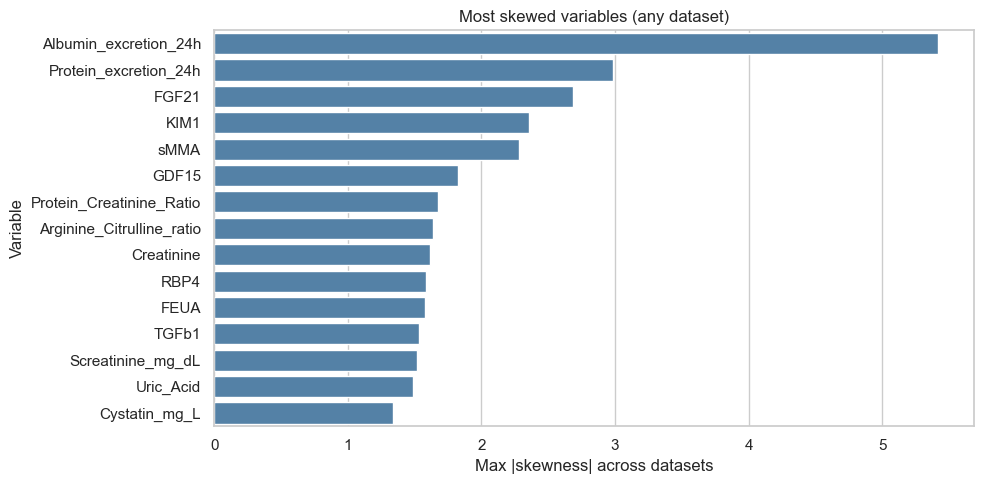

In [4]:
# Flag variables that remain skewed even after log transform
if not skew_summary.empty:
    flagged = skew_summary[skew_summary['abs_skewness'] >= 1.0].copy()
    print(f'Variables with |skew| >= 1 in at least one dataset: {flagged["Variable"].nunique()}')
    display(flagged.groupby(['Dataset', 'skew_category']).size().unstack(fill_value=0))

    plt.figure(figsize=(10, 5))
    top = skew_summary.groupby('Variable')['abs_skewness'].max().sort_values(ascending=False).head(15)
    sns.barplot(x=top.values, y=top.index, color='steelblue')
    plt.xlabel('Max |skewness| across datasets')
    plt.ylabel('Variable')
    plt.title('Most skewed variables (any dataset)')
    plt.tight_layout()
    plt.show()

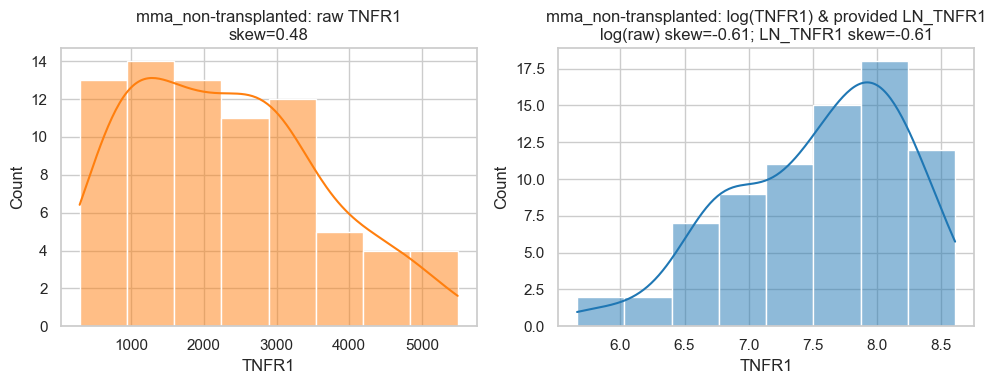

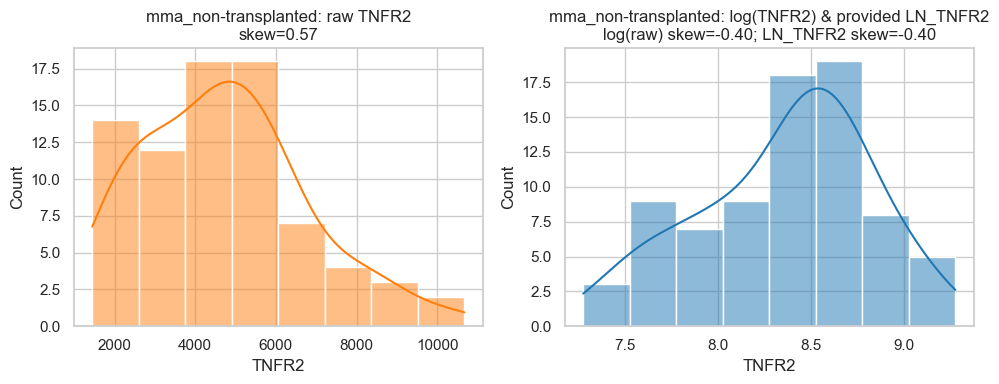

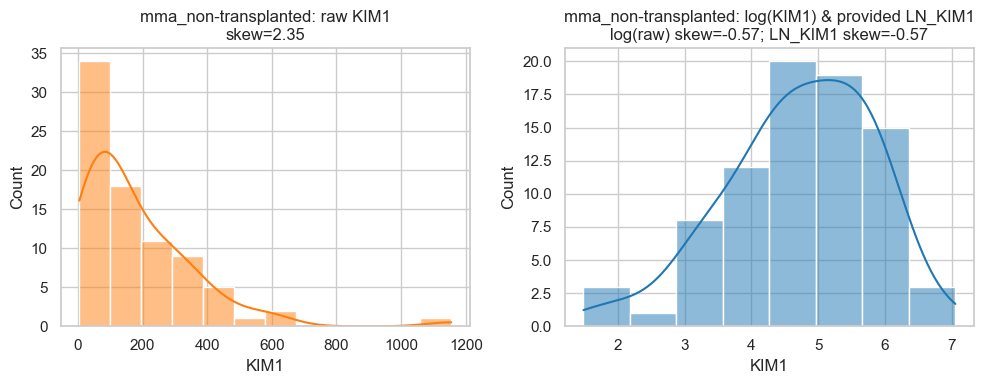

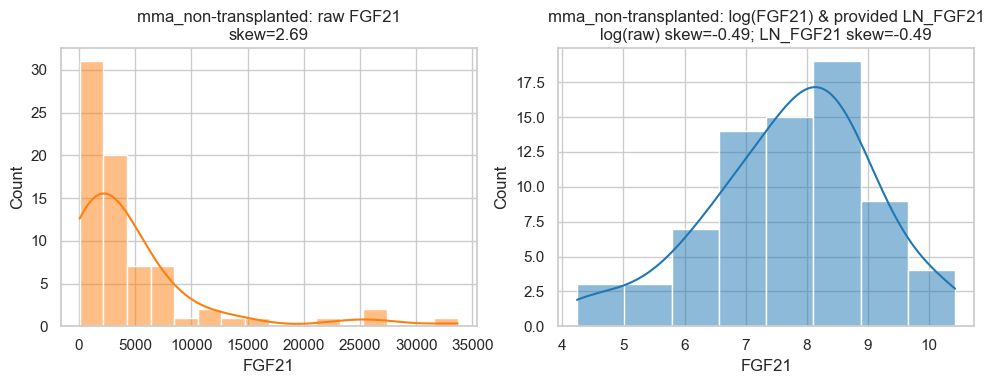

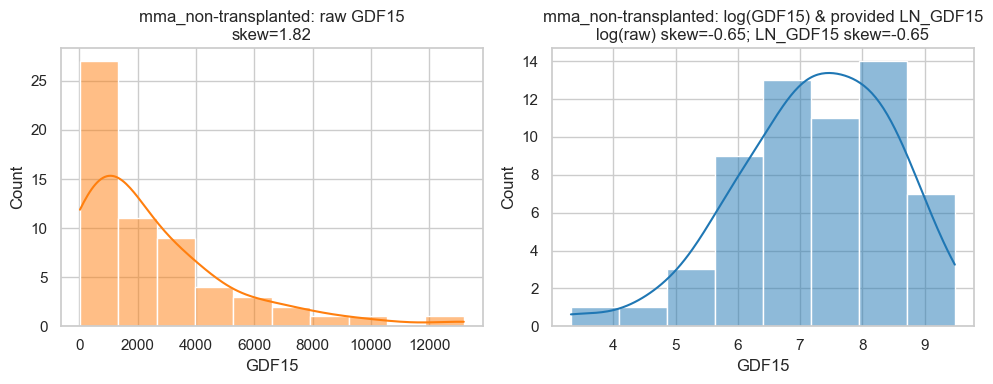

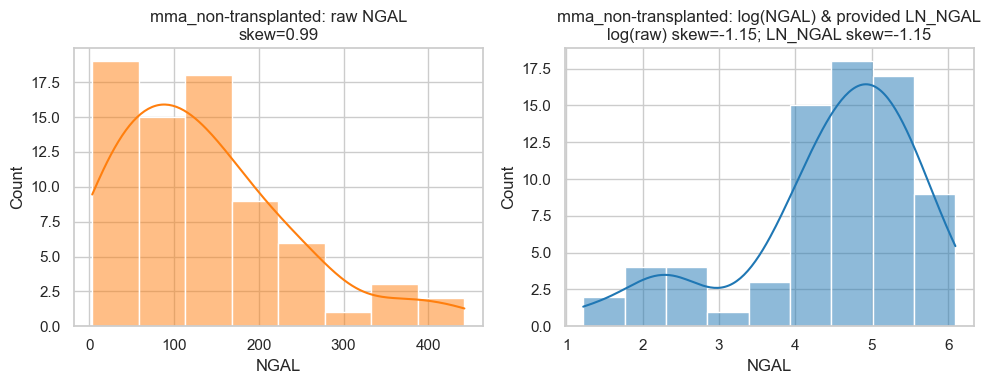

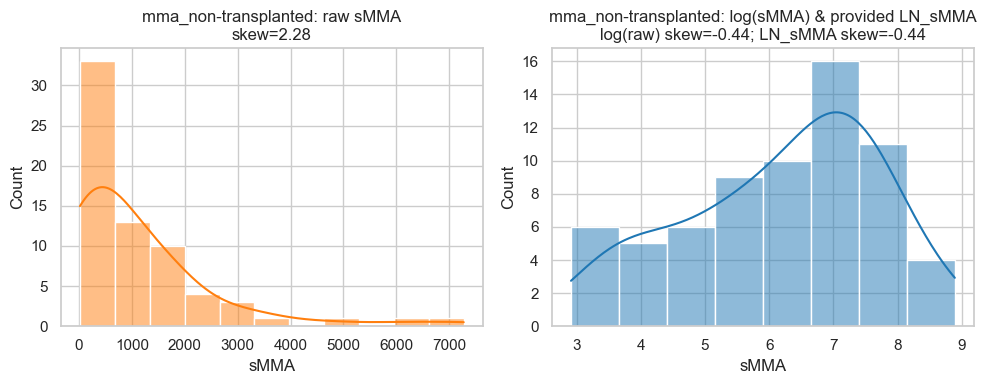

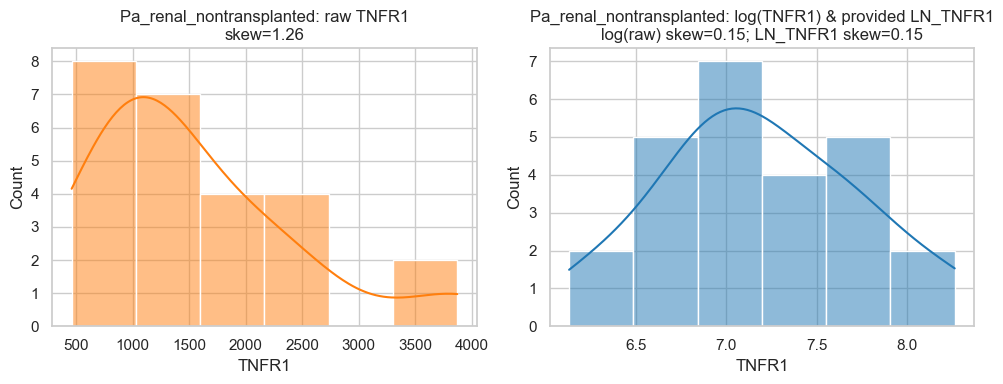

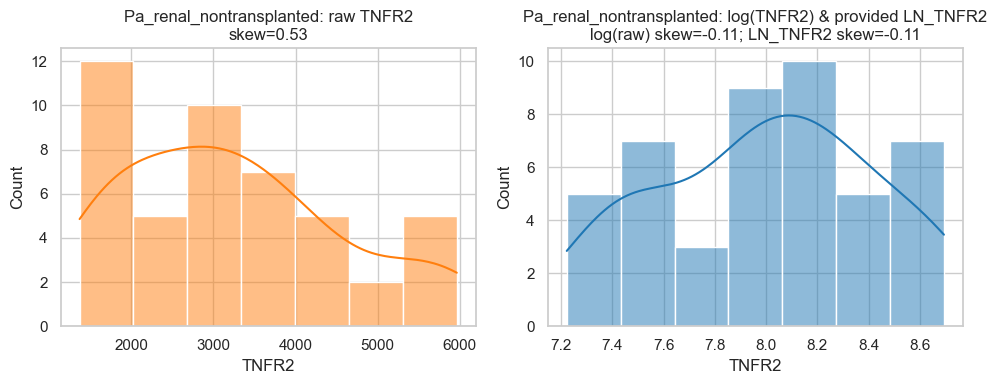

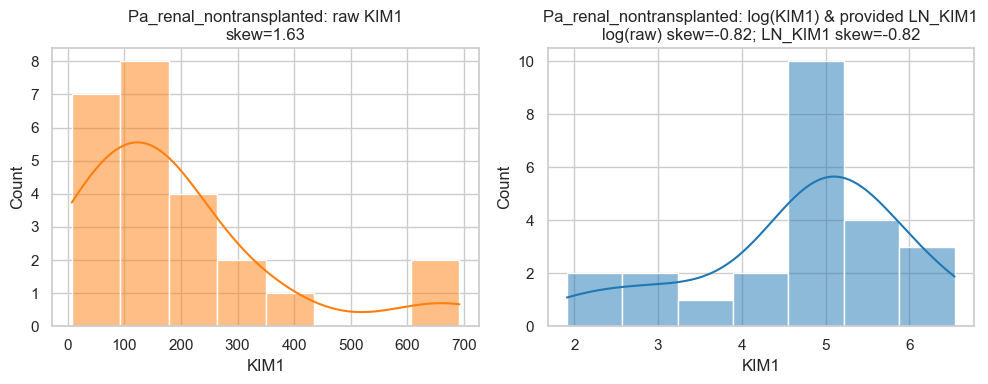

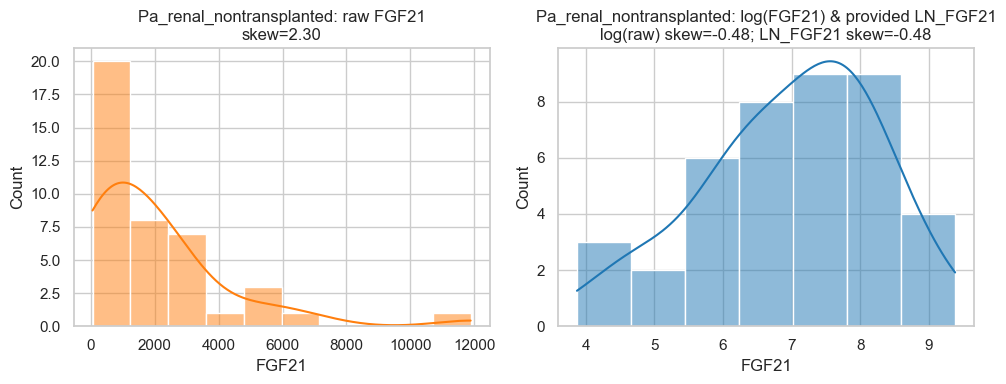

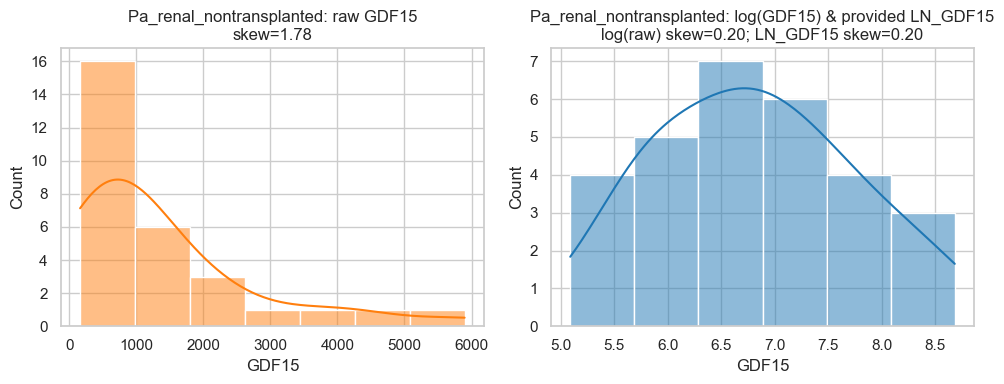

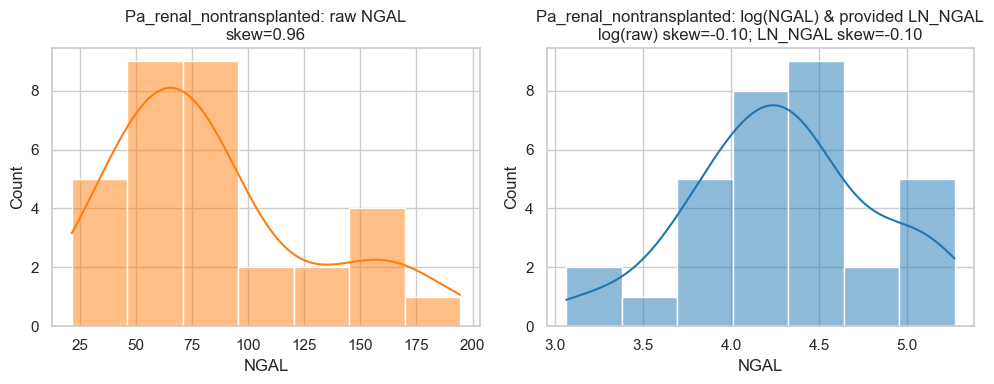

In [5]:
def plot_raw_vs_log(df, dataset_name, raw_col, ln_col=None):
    if raw_col not in df.columns:
        return

    raw = pd.to_numeric(df[raw_col], errors='coerce')
    raw = raw[raw > 0].dropna()
    if len(raw) < 5:
        return

    log_raw = np.log(raw)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(raw, kde=True, ax=axes[0], color='tab:orange')
    axes[0].set_title(f'{dataset_name}: raw {raw_col}\nskew={skew(raw):.2f}')

    sns.histplot(log_raw, kde=True, ax=axes[1], color='tab:blue')
    axes[1].set_title(f'{dataset_name}: log({raw_col})\nskew={skew(log_raw):.2f}')

    if ln_col and ln_col in df.columns:
        ln_vals = pd.to_numeric(df[ln_col], errors='coerce').dropna()
        if len(ln_vals) >= 5:
            axes[1].set_title(
                f'{dataset_name}: log({raw_col}) & provided {ln_col}\n'
                f'log(raw) skew={skew(log_raw):.2f}; {ln_col} skew={skew(ln_vals):.2f}'
            )

    plt.tight_layout()
    plt.show()


RAW_TO_LN = {
    'TNFR1': 'LN_TNFR1',
    'TNFR2': 'LN_TNFR2',
    'KIM1': 'LN_KIM1',
    'FGF21': 'LN_FGF21',
    'GDF15': 'LN_GDF15',
    'NGAL': 'LN_NGAL',
    'sMMA': 'LN_sMMA',
}

for ds_name in ['mma_non-transplanted', 'Pa_renal_nontransplanted']:
    if ds_name not in loaded:
        continue
    df = loaded[ds_name]
    for raw_col, ln_col in RAW_TO_LN.items():
        plot_raw_vs_log(df, ds_name, raw_col, ln_col)